In [7]:
import os
from pathlib import Path

# Set project root automatically based on notebook location
PROJECT_ROOT = Path.cwd().parents[0]
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project Root:", PROJECT_ROOT)
print("Raw Data Folder:", RAW_DATA_DIR)
print("Files detected:", os.listdir(RAW_DATA_DIR))


Project Root: c:\Rutgers MSDS\Coursework\Regression and Time Series\f1_finishing_times_regression
Raw Data Folder: c:\Rutgers MSDS\Coursework\Regression and Time Series\f1_finishing_times_regression\data\raw
Files detected: ['.gitkeep', 'circuits.csv', 'constructors.csv', 'constructor_results.csv', 'constructor_standings.csv', 'drivers.csv', 'driver_standings.csv', 'lap_times.csv', 'pit_stops.csv', 'qualifying.csv', 'races.csv', 'results.csv', 'seasons.csv', 'sprint_results.csv', 'status.csv']


### Build Modeling Dataset

In [8]:
from src.data.make_dataset import build_modeling_dataset

df = build_modeling_dataset()   # merges races + results + drivers + constructors
df.head(), df.shape


(   resultId  raceId  driverId  constructorId number  grid position  \
 0         1      18         1              1     22     1        1   
 1         2      18         2              2      3     5        2   
 2         3      18         3              3      7     7        3   
 3         4      18         4              4      5    11        4   
 4         5      18         5              1     23     3        5   
 
   positionText  positionOrder  points  ...  nationality  \
 0            1              1    10.0  ...      British   
 1            2              2     8.0  ...       German   
 2            3              3     6.0  ...       German   
 3            4              4     5.0  ...      Spanish   
 4            5              5     4.0  ...      Finnish   
 
                                        url_driver constructorRef  \
 0     http://en.wikipedia.org/wiki/Lewis_Hamilton        mclaren   
 1      http://en.wikipedia.org/wiki/Nick_Heidfeld     bmw_sauber   
 2 

### Exploratory Data Analysis

In [9]:
df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   resultId                 26759 non-null  int64  
 1   raceId                   26759 non-null  int64  
 2   driverId                 26759 non-null  int64  
 3   constructorId            26759 non-null  int64  
 4   number                   26759 non-null  object 
 5   grid                     26759 non-null  int64  
 6   position                 26759 non-null  object 
 7   positionText             26759 non-null  object 
 8   positionOrder            26759 non-null  int64  
 9   points                   26759 non-null  float64
 10  laps                     26759 non-null  int64  
 11  time                     26759 non-null  object 
 12  milliseconds             26759 non-null  object 
 13  fastestLap               26759 non-null  object 
 14  rank                  

resultId                   0
raceId                     0
driverId                   0
constructorId              0
number                     0
grid                       0
position                   0
positionText               0
positionOrder              0
points                     0
laps                       0
time                       0
milliseconds               0
fastestLap                 0
rank                       0
fastestLapTime             0
fastestLapSpeed            0
statusId                   0
year                       0
round                      0
circuitId                  0
name                       0
date                       0
time_race                  0
url                        0
fp1_date                   0
fp1_time                   0
fp2_date                   0
fp2_time                   0
fp3_date                   0
fp3_time                   0
quali_date                 0
quali_time                 0
sprint_date                0
sprint_time   

In [13]:
import pandas as pd
import numpy as np

# Ensure finishing_time_ms is numeric
df['finishing_time_ms'] = pd.to_numeric(df['finishing_time_ms'], errors='coerce')

df['finishing_time_ms'].isna().sum(), df.shape


(19079, (26759, 51))

In [14]:
df_clean = df[(df['finishing_time_ms'].notna()) & (df['finishing_time_ms'] > 0)]
df_clean.shape


(7680, 51)

c:\Users\raksh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


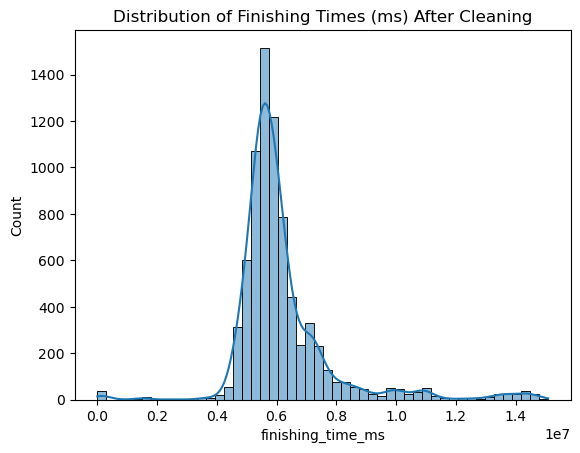

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_clean['finishing_time_ms'], bins=50, kde=True)
plt.title("Distribution of Finishing Times (ms) After Cleaning")
plt.show()


### Exploratory Visualizations (to understand relationships)

##### 1. Finishing Time vs Grid Position

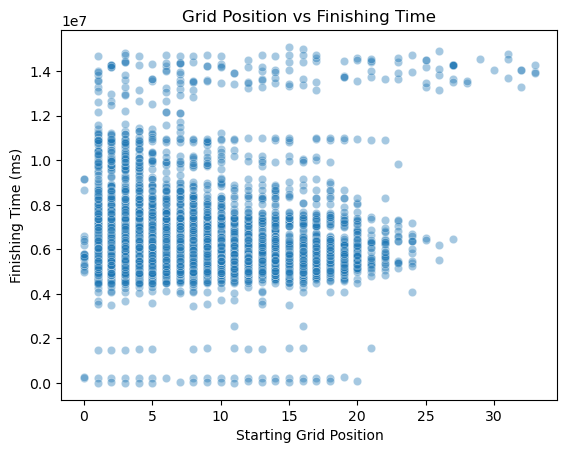

In [17]:
sns.scatterplot(data=df_clean, x="grid", y="finishing_time_ms", alpha=0.4)
plt.title("Grid Position vs Finishing Time")
plt.xlabel("Starting Grid Position")
plt.ylabel("Finishing Time (ms)")
plt.show()


##### 2. Constructor vs Finishing Times:

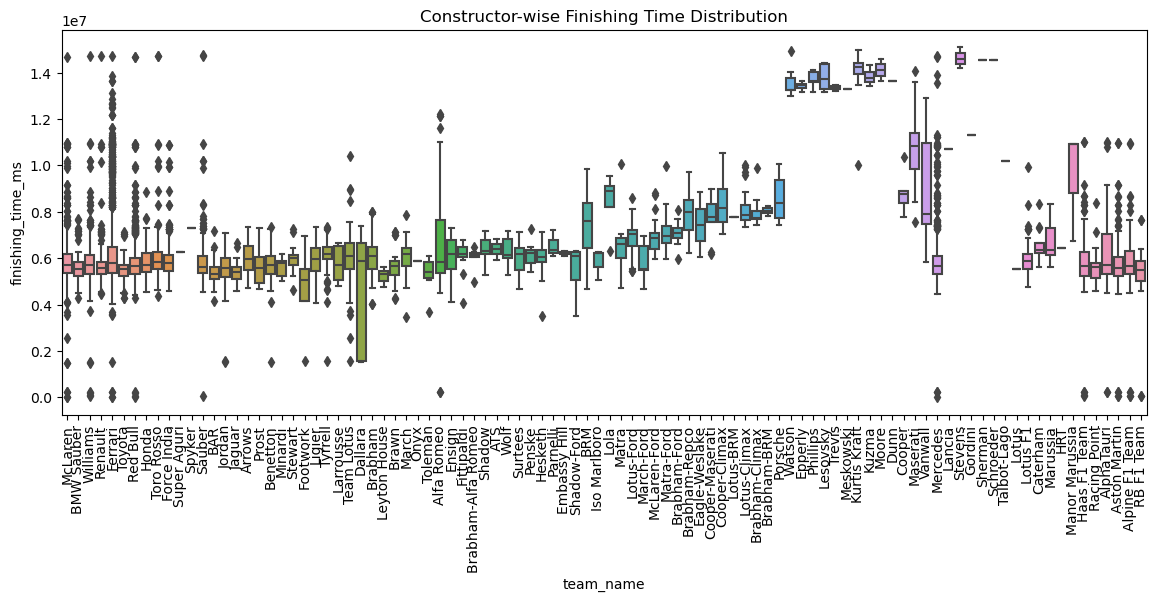

In [19]:
plt.figure(figsize=(14,5))
sns.boxplot(data=df_clean, x="team_name", y="finishing_time_ms")
plt.xticks(rotation=90)
plt.title("Constructor-wise Finishing Time Distribution")
plt.show()


##### 3.Baseline Regression Model Using Statsmodels

In [31]:
# ============================================================
# 1. Load Cleaned Data (from earlier df_clean)
# ============================================================
import pandas as pd
import statsmodels.api as sm

df_model = df_clean.copy()   # use pre-cleaned dataset


# ============================================================
# 2. Define predictors
# ============================================================
predictors = ["grid", "team_name", "driver_ref", "track", "year"]


# ============================================================
# 3. Prepare X and y
# ============================================================
# y target
y = pd.to_numeric(df_model["finishing_time_ms"], errors='coerce')

# One-hot encode categorical variables
X = pd.get_dummies(df_model[predictors], drop_first=True)

# Convert bool to int (very important!)
X = X.astype("int64")

# Convert to numeric for safety
X = X.apply(pd.to_numeric, errors='coerce')


# ============================================================
# 4. Drop rows with NaN in either X or y
# ============================================================
data = pd.concat([y, X], axis=1).dropna()

y_clean = data.iloc[:,0].astype(float)
X_clean = data.iloc[:,1:].astype(float)

X_clean = sm.add_constant(X_clean)  # add intercept


# ============================================================
# 5. Fit Baseline OLS Model
# ============================================================
model = sm.OLS(y_clean, X_clean).fit()

# ============================================================
# 6. View Results
# ============================================================
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      finishing_time_ms   R-squared:                       0.721
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     39.31
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:01:53   Log-Likelihood:            -1.1603e+05
No. Observations:                7680   AIC:                         2.330e+05
Df Residuals:                    7205   BIC:                         2.363e+05
Df Model:                         474                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [34]:
for col in df_model.columns:
    print(col)

resultId
raceId
driverId
constructorId
number
grid
position
positionText
positionOrder
points
laps
time
milliseconds
fastestLap
rank
fastestLapTime
fastestLapSpeed
statusId
year
round
circuitId
name
date
time_race
url
fp1_date
fp1_time
fp2_date
fp2_time
fp3_date
fp3_time
quali_date
quali_time
sprint_date
sprint_time
driverRef
number_driver
code
forename
surname
dob
nationality
url_driver
constructorRef
name_constructor
nationality_constructor
url_constructor
finishing_time_ms
track
team_name
driver_ref


In [38]:
df_2013_valid = df_clean[(df_clean['year'] >= 2013) & (df_clean['finishing_time_ms'].notna())]
print("Valid rows post-2013 with finishing time:", df_2013_valid.shape[0])


Valid rows post-2013 with finishing time: 2651


In [40]:
constructor_map = {
    # Long-term lineage groups
    "Lotus F1": "Alpine",      # Lotus → Renault → Alpine path
    "Renault": "Alpine",
    "Alpine F1 Team": "Alpine",
    
    "Force India": "Aston Martin",
    "Racing Point": "Aston Martin",
    "Aston Martin": "Aston Martin",

    "Toro Rosso": "RB F1 Team",
    "AlphaTauri": "RB F1 Team",
    "RB F1 Team": "RB F1 Team",
    
    "Sauber": "Alfa Romeo",        # Sauber <-> Alfa interchange
    "Alfa Romeo": "Alfa Romeo",
    
    # Teams that disappeared — no successor
    "Marussia": "Marussia",
    "Manor Marussia": "Marussia",
    "Caterham": "Caterham",
    
    # Teams that stayed consistent
    "Ferrari": "Ferrari",
    "Red Bull": "Red Bull",
    "Mercedes": "Mercedes",
    "McLaren": "McLaren",
    "Williams": "Williams",
    "Haas F1 Team": "Haas",
    "Haas": "Haas",   # just in case
}


In [45]:
# Keep only modern hybrid era races
df_final = df_clean[df_clean['year'] >= 2013].copy()

# Apply constructor standardization mapping
df_final.loc[:, 'constructor_std'] = (
    df_final['team_name'].map(constructor_map).fillna(df_final['team_name'])
)

# Check results
print("Rows after 2013 filter:", df_final.shape[0])
print("\nConstructor counts after consolidation:\n")
print(df_final['constructor_std'].value_counts())


Rows after 2013 filter: 2651

Constructor counts after consolidation:

constructor_std
Mercedes        445
Ferrari         399
Red Bull        387
McLaren         271
Aston Martin    266
Alpine          217
RB F1 Team      192
Williams        192
Alfa Romeo      144
Haas            121
Marussia         10
Caterham          7
Name: count, dtype: int64


In [46]:
import statsmodels.api as sm
import pandas as pd

# target
y = pd.to_numeric(df_final['finishing_time_ms'], errors='coerce')

# updated predictors
predictors = ["grid", "constructor_std", "driver_ref", "track", "year"]
X = pd.get_dummies(df_final[predictors], drop_first=True)

# ensure numeric
X = X.astype('float64')

# drop rows with missing
data = pd.concat([y,X], axis=1).dropna()
y_c = data.iloc[:,0]
X_c = sm.add_constant(data.iloc[:,1:])

# fit model
model = sm.OLS(y_c, X_c).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      finishing_time_ms   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     13.41
Date:                Thu, 04 Dec 2025   Prob (F-statistic):          9.71e-179
Time:                        11:05:46   Log-Likelihood:                -40389.
No. Observations:                2651   AIC:                         8.100e+04
Df Residuals:                    2541   BIC:                         8.165e+04
Df Model:                         109                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     